In [1]:
from scripts.utils import check_data, preprocess_data, save_data
from scripts.utils import PROJECT_PATH, DATA_PATH, RESULTS_PATH, CELLTYPE_MAP, HISTOTYPE_MAP, ANNDATA_MAP, SUBSETS_CONFIG

from scripts.gene_subsampling import neyman_subsample
from scripts.studies import study_sparsity, study_sparsity_with_trajectories, study_complete_sparsity, study_group_sparsity, study_group_sparsity_exclude, study_sparsity_stdthinning
import numpy as np

from scripts.clustering import cluster_data, find_best_resolution, find_best_resolution_linspace, best_leiden_run

from scripts.utils import plot_UMAP, update_data
import os

%load_ext autoreload
%autoreload 2

c:\Users\mayeu\anaconda3\envs\work\Lib\site-packages\louvain\__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
c:\Users\mayeu\anaconda3\envs\work\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
celltype="Myeloid cells"

myeloid_cells = check_data(celltype=celltype,data_path=DATA_PATH)
if myeloid_cells is None:
    myeloid_cells = preprocess_data(celltype=celltype, with_subsets_config=True, n_neighbors=15, n_comps=100, random_state=42, verbose=False)
    save_data(data=myeloid_cells, data_path=f"{DATA_PATH}\\{ANNDATA_MAP[celltype]}")

In [3]:
myeloid_cells

AnnData object with n_obs × n_vars = 13785 × 2421
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'cellstates_tme', 'histotype', 'celltype', 'celltype_normal_adrenal', 'celltype_label', 'histotype_label'
    var: 'features'
    uns: 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [ ]:
n_cells=1e3
myeloid_cells =neyman_subsample(data=myeloid_cells,target_labels=["Myeloid cells"],label_col="celltype_label",stratify_by=["cellstates_tme"],n_target=20e3)
myeloid_cells = update_data(data=myeloid_cells)

n_target=20000.0 dépasse le nombre de cellules disponibles pour '['Myeloid cells']' (13785).


c:\Users\mayeu\Desktop\TRAVAIL\MVA\Cours\Projet médecin\scripts\scripts\utils.py:251: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  data.X = residuals
c:\Users\mayeu\anaconda3\envs\work\Lib\site-packages\scanpy\preprocessing\_pca\__init__.py:384: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca


Ratio=0.010


c:\Users\mayeu\Desktop\TRAVAIL\MVA\Cours\Projet médecin\scripts\scripts\clustering.py:25: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(data,resolution=resolution,key_added='leiden_temp', random_state=random_state)




Ratio=0.037


Ratio=0.063


Ratio=0.090


Ratio=0.117


Ratio=0.143


Ratio=0.170


Ratio=0.197


Ratio=0.223


Ratio=0.250


Ratio=0.010


Ratio=0.037


Ratio=0.063


Ratio=0.090


Ratio=0.117


[W 2026-03-19 10:41:43,597] Trial 10 failed with parameters: {'resolution': 1.8072159473180451} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\mayeu\anaconda3\envs\work\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "c:\Users\mayeu\Desktop\TRAVAIL\MVA\Cours\Projet médecin\scripts\scripts\clustering.py", line 126, in <lambda>
    lambda trial: objective(trial, data, true_labels=true_labels, n_neighbors=n_neighbors, n_comps=n_comps, n_seeds=1),
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\mayeu\Desktop\TRAVAIL\MVA\Cours\Projet médecin\scripts\scripts\clustering.py", line 90, in objective
    output = cluster_data(data=data, true_labels=true_labels, n_neighbors=n_neighbors,resolution=resolution,n_comps=n_comps,random_state=seed,show=False)
      

KeyboardInterrupt: 

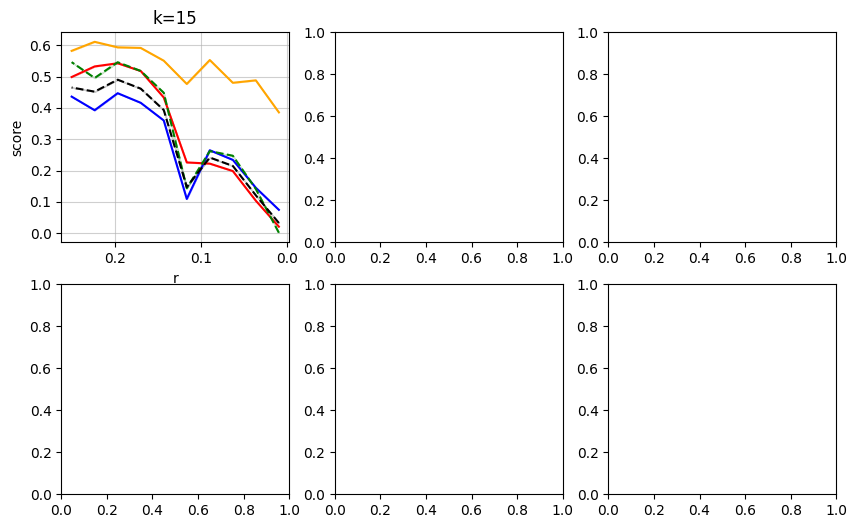

In [4]:
n_points_ratio = 10
n_runs = 1
n_neighbors_candidates = [15,25,50,100,200]

ratio_candidates = np.linspace(0.01,0.25,n_points_ratio)
labels = myeloid_cells.obs["cellstates_tme"]
show = True

sparsity_results = study_complete_sparsity(myeloid_cells,labels=labels,ratio_candidates=ratio_candidates,n_runs=n_runs, n_neighbors_candidates=n_neighbors_candidates, show=show)

In [ ]:
n_points_ratio = 10
n_run = 25
n_neighbors_candidates = [15,25,50,100,200]

ratio_candidates = np.linspace(0.01,1,n_points_ratio)
labels = myeloid_cells.obs["cellstates_tme"]
show = True

sparsity_results = study_complete_sparsity(myeloid_cells,labels=labels,ratio_candidates=ratio_candidates,n_runs=n_runs, n_neighbors_candidates=n_neighbors_candidates, show=show)

Ratio=0.010


Ratio=0.340


Ratio=0.670


Ratio=1.000




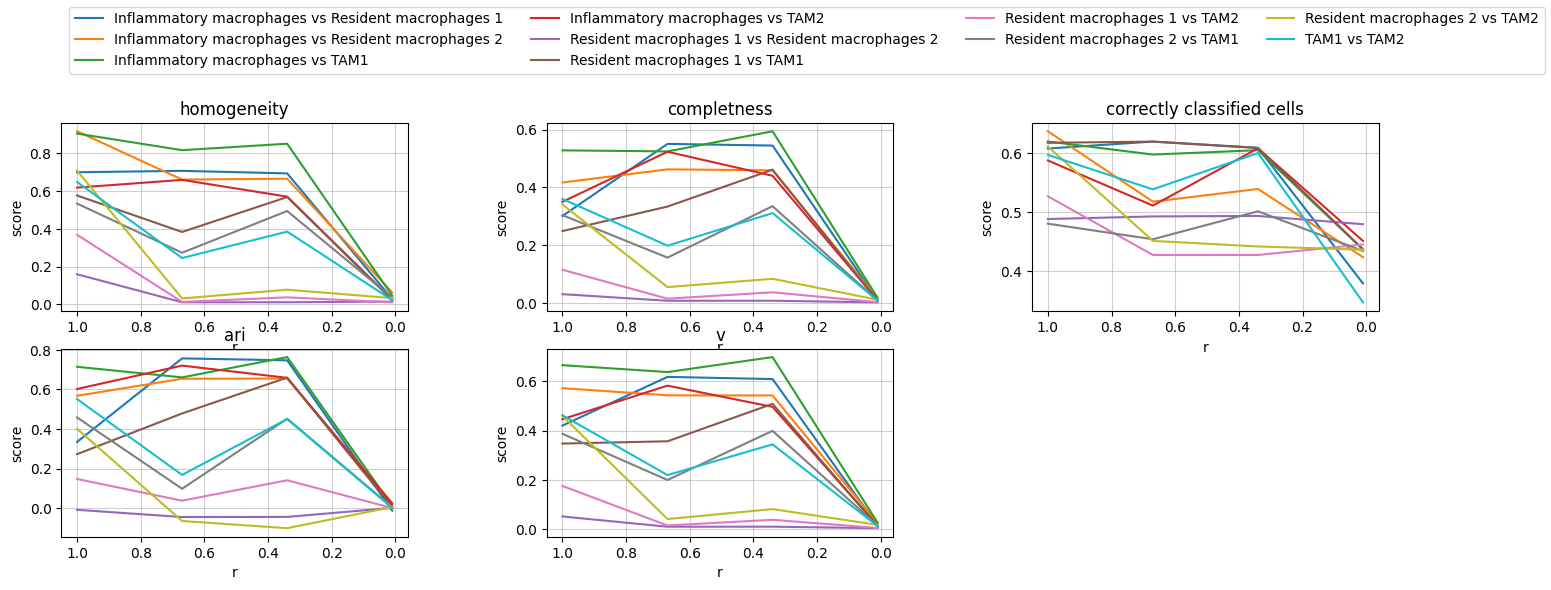

{'homogeneity': {'Inflammatory macrophages vs Resident macrophages 1': [np.float64(0.02830482335554489),
   np.float64(0.6927587356314476),
   np.float64(0.7061941688039526),
   np.float64(0.6987551964089307)],
  'Inflammatory macrophages vs Resident macrophages 2': [np.float64(0.06331596497154028),
   np.float64(0.6646899864616866),
   np.float64(0.6599493655701837),
   np.float64(0.91541656960277)],
  'Inflammatory macrophages vs TAM1': [np.float64(0.04570099233496178),
   np.float64(0.8496305396989958),
   np.float64(0.8155298186867133),
   np.float64(0.9032048396612854)],
  'Inflammatory macrophages vs TAM2': [np.float64(0.025009571934044066),
   np.float64(0.5699441198045666),
   np.float64(0.6584586704900497),
   np.float64(0.6175345709443153)],
  'Resident macrophages 1 vs Resident macrophages 2': [np.float64(0.01494425048560586),
   np.float64(0.011555871822134526),
   np.float64(0.011312506610954705),
   np.float64(0.15953739635147765)],
  'Resident macrophages 1 vs TAM1': [np

In [5]:
n_points_ratio = 4
n_run = 1
ratio_candidates = np.linspace(0.01,1,n_points_ratio)
n_neighbors=20
labels = myeloid_cells.obs["cellstates_tme"]

study_group_sparsity(myeloid_cells,labels=labels,ratio_candidates=ratio_candidates,n_runs=n_runs, n_neighbors=n_neighbors, search_resolution_method="optuna", show=show)

Ratio=0.010


Ratio=0.120


Ratio=0.230


Ratio=0.340


Ratio=0.450


Ratio=0.560


Ratio=0.670


Ratio=0.780


Ratio=0.890


Ratio=1.000




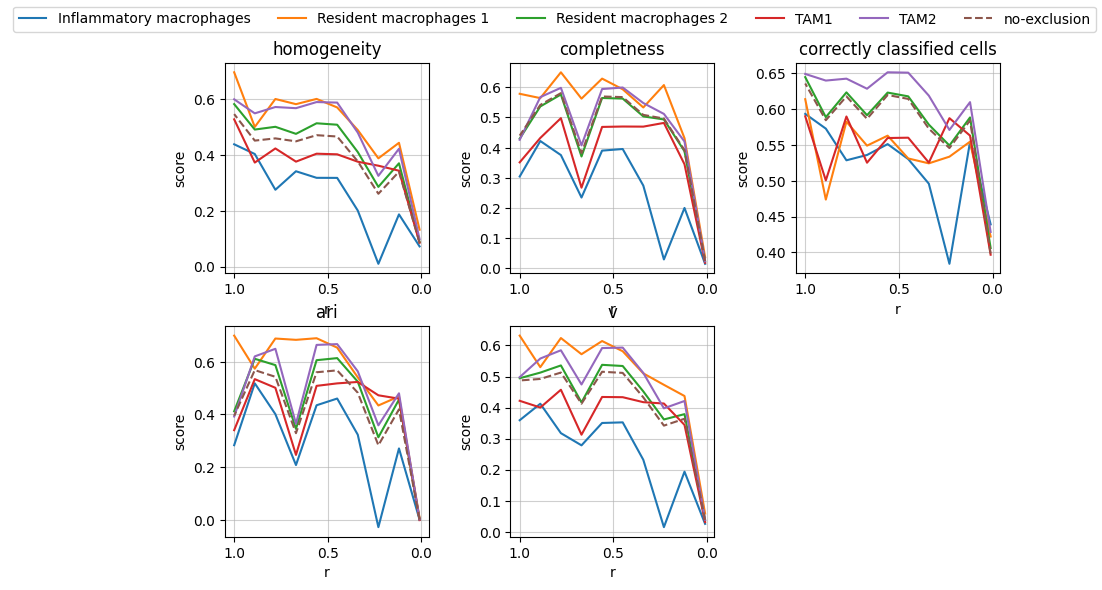

{'homogeneity': {'Inflammatory macrophages': [np.float64(0.07204825784394074),
   np.float64(0.18684956492563679),
   np.float64(0.009741608501906956),
   np.float64(0.20048888442272872),
   np.float64(0.31758673529961373),
   np.float64(0.31782081215159563),
   np.float64(0.3413489399383894),
   np.float64(0.27505628337897076),
   np.float64(0.4031374607763608),
   np.float64(0.4379781127946082)],
  'Resident macrophages 1': [np.float64(0.13199641582221872),
   np.float64(0.44326134247408194),
   np.float64(0.38769947905776164),
   np.float64(0.4890120736069257),
   np.float64(0.5700246913520356),
   np.float64(0.6005417940812239),
   np.float64(0.581710475411385),
   np.float64(0.6002759885125006),
   np.float64(0.5001191773484982),
   np.float64(0.6958956335324737)],
  'Resident macrophages 2': [np.float64(0.08718609703421362),
   np.float64(0.3698757932540956),
   np.float64(0.28539844470515463),
   np.float64(0.41016097176919003),
   np.float64(0.5080683447105979),
   np.float64(0

In [6]:
n_points_ratio = 10
n_run = 1
ratio_candidates = np.linspace(0.01,1,n_points_ratio)
n_neighbors=20
study_group_sparsity_exclude(myeloid_cells,labels=labels,ratio_candidates=ratio_candidates,n_runs=n_runs, n_neighbors=n_neighbors, search_resolution_method="optuna", show=show)

In [ ]:
n_points_ratio = 10
n_run = 25
ratio_candidates = np.linspace(0.01,0.25,n_points_ratio)
n_neighbors=20
study_group_sparsity_exclude(myeloid_cells,labels=labels,ratio_candidates=ratio_candidates,n_runs=n_runs, n_neighbors=n_neighbors, search_resolution_method="optuna", show=show)

In [ ]:
# n_neighbors = 20

# thinned_cells = thinning(myeloid_cells,reduction_ratio=0.85,same_reads=False,copy=True)
# thinned_cells = update_data(thinned_cells, n_neighbors=n_neighbors,n_comps=100,random_state=42)
# plot_UMAP(thinned_cells)

# mask = myeloid_cells.obs["cellstates_tme"] != 'TAM2'
# without_inf = myeloid_cells[mask]
# thinned_cells_without_inf = thinning(without_inf,reduction_ratio=0.85,same_reads=False,copy=True)
# thinned_cells_without_inf = update_data(thinned_cells_without_inf, n_neighbors=n_neighbors,n_comps=100,random_state=42)
# plot_UMAP(thinned_cells_without_inf)